
# Lab_4: FDM-capacitor

### Potential and Electric field from a capacitor

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:

\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}
\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}

However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

* Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

* Compute numerically (use finite difference method) the electric field.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" width="500" height="300" />

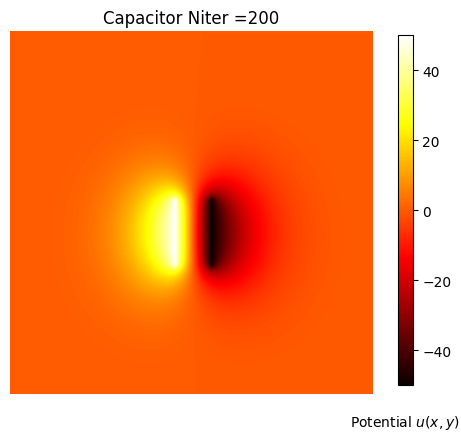

In [ ]:
# let's construc you own rutine. As an example:
from capacitor import capacitor_df #my rutine

# Plot imshow
Niter = 200
V = capacitor_df(Niter)
fig, ax = plt.subplots(figsize=(5,5) )
im = ax.imshow(V.copy(),cmap="hot",interpolation="bilinear",)
ax.set_axis_off()
ax.set_title('Capacitor Niter =%.1d'%Niter)

fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.9, 0.15, 0.03, 0.7])
cbar_ax.set_xlabel("Potential $u(x,y)$", labelpad=20)
fig.colorbar(im, cax=cbar_ax)
plt.show()

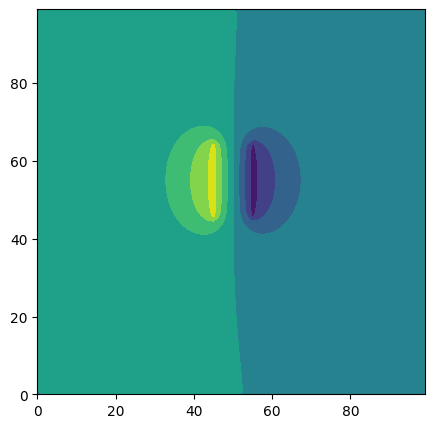

In [ ]:
plt.subplots(figsize=(5,5) )
plt.contourf(V)
plt.show()

### My own rutine for Potential and Electric field from a capacitor


In [8]:
# Librerias

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necesario para 3D

In [4]:
# Traemos nuestro código anterior del lab_4 y lo mejoramos para nuestro Lab_4:
# Tenieendo en cuenta que las condiciones de frontera serán el nuevo arreglo Para nuestro código anterior:

def Laplace(V_0, condiciones , tol, max_iter=10000): 

    V_new = V_0.copy()
    V_old = V_0.copy()

    M_Diferencia = float('inf')
    contador = 0

    while M_Diferencia > tol and contador < max_iter:
        V_old = V_new.copy()

        # Jacobi vectorizado
        V_new[1:-1,1:-1] = 0.25*(
            V_old[2:,1:-1] + 
            V_old[:-2,1:-1] + 
            V_old[1:-1,2:] + 
            V_old[1:-1,:-2]
        )

        # Condiciones de frontera y barras fijas:
        V_new[condiciones] = V_0 [condiciones]

        # Error
        M_Diferencia = np.max(np.abs(V_new - V_old))
        contador += 1

    print(f'Convergió en {contador} iteraciones con error {M_Diferencia:.6e}')

    return V_new



In [10]:

# Utilizando la función:


N = 100
V_0 = np.zeros((N,N))

frontera = np.zeros_like(V_0, dtype=bool)

# Placa izquierda
V_0[35:65, 25:30] = 10
frontera[35:65, 25:30] = True
# Placa derecha
V_0[35:65, 75:80] = -10
frontera[35:65, 75:80] = True

# Bordes (condición de V = 0 en el "inf" )
frontera[0,:] = True
frontera[-1,:] = True
frontera[:,0] = True
frontera[:,-1] = True

# Resolver
V = Laplace(V_0, frontera, tol=1e-4)


Convergió en 1966 iteraciones con error 9.981206e-05


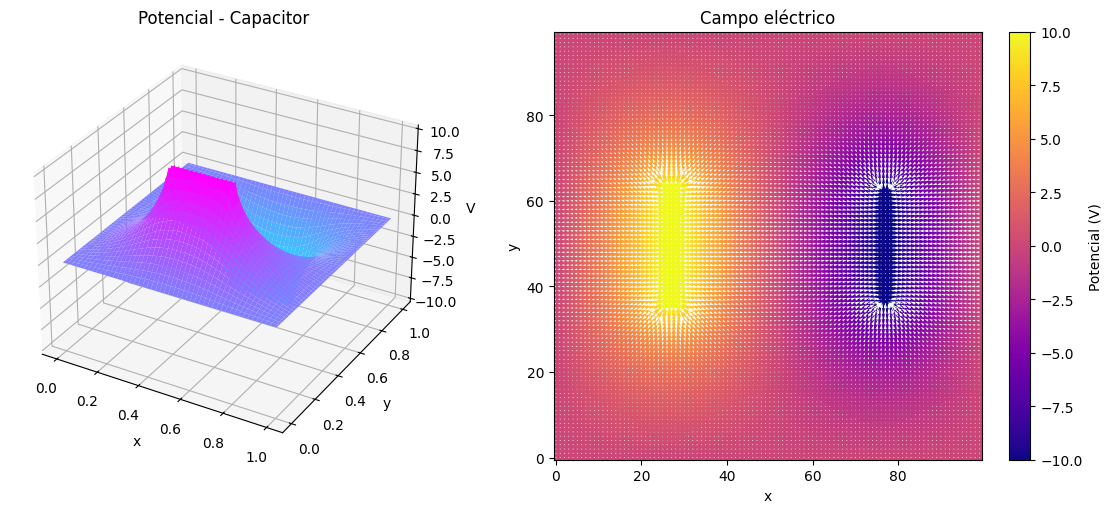

In [11]:

# Campo eléctrico
Ey, Ex = np.gradient(-V)

# Crear figura
fig = plt.figure(figsize=(12,5))

# 🔹 Subplot 1: Superficie 3D
ax1 = fig.add_subplot(1,2,1, projection='3d')
ax1.plot_surface(X, Y, V, cmap='cool')
ax1.set_title("Potencial - Capacitor")
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_zlabel("V")

# 🔹 Subplot 2: Campo eléctrico 2D
ax2 = fig.add_subplot(1,2,2)
im = ax2.imshow(V, cmap='plasma', origin='lower')

# Flechas (campo eléctrico)
ax2.quiver(Ex, Ey, color='white')

ax2.set_title("Campo eléctrico")
ax2.set_xlabel("x")
ax2.set_ylabel("y")

# Barra de color (solo una, asociada al potencial)
fig.colorbar(im, ax=ax2, label='Potencial (V)')

plt.tight_layout()
plt.show()
